<H3>3-layer neural network for MNIST digits detection, created from scratch using numpy</h3>
<a href="https://www.kaggle.com/code/scaomath/simple-neural-network-for-mnist-numpy-from-scratch/notebook">Kaggle link for help</a><br>
<a href="https://medium.com/data-science/derivative-of-the-softmax-function-and-the-categorical-cross-entropy-loss-ffceefc081d1">Some maths for cross entropy loss derivative</a>
<table>
    <tr>
        <th>Forward</th>
        <th>Backward</th>
    </tr>
    <tr>
        <td>
            <pre>
X  (m × 784)
  → Z1 = X @ W1.T + b1        → (m × 256)
  → A1 = ReLU(Z1)             → (m × 256)         
  → Z2 = A1 @ W2.T + b2       → (m × 10)
  → A2 = softmax(Z2)
            </pre>
        </td>
        <td>
            <pre>
dZ2 = A2 - Y                  → (m × 10)
dW2 = dZ2.T @ A1              → (10 × 256)
db2 = sum(dZ2)                → (1 × 10)

dZ1 = (dZ2 @ W2) * ReLU'(Z1)  → (m × 256)
dW1 = dZ1.T @ X               → (256 × 784)
db1 = sum(dZ1)                → (1 × 256)
            </pre>
        </td>
    </tr>
</table>




In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
from keras.datasets import mnist

In [2]:
(x_train, Y_train), (x_test, Y_test) = mnist.load_data()
print("Train : ", x_train.shape, Y_train.shape)
print("Test : ", x_test.shape, Y_test.shape)

Train :  (60000, 28, 28) (60000,)
Test :  (10000, 28, 28) (10000,)


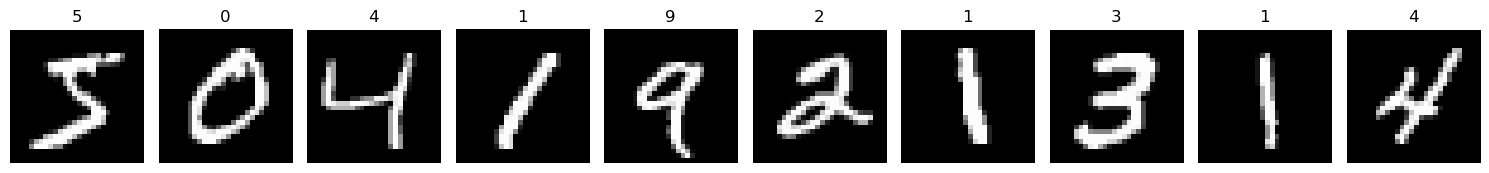

In [3]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(Y_train[i])
plt.tight_layout()
plt.show()

In [4]:
x_train = x_train.reshape(60000, 28*28)/255.0
x_test = x_test.reshape(10000, 28*28)/255.0

print(x_train.shape, Y_train.shape)
print("x_train max:", np.max(x_train))
print("x_train mean:", np.mean(x_train))
assert not np.isnan(x_train).any()
assert not np.isinf(x_train).any()

(60000, 784) (60000,)
x_train max: 1.0
x_train mean: 0.1306604762738429


In [5]:
# # # Reduce the dataset size for faster training and debugging
# x_train = x_train[:5000]
# Y_train = Y_train[:5000]
# x_test = x_test[:32]
# Y_test = Y_test[:32]

In [6]:
def relu(z):
    """
    Apply the ReLU (Rectified Linear Unit) activation function.

    Parameters:
    z (numpy.ndarray): Input array.

    Returns:
    numpy.ndarray: Output array where each element is the maximum of 0 and the corresponding input element.
    """
    return np.maximum(0, z)

def softmax(X):
    """
    Apply the softmax function to convert logits to probabilities.

    Parameters:
    X (numpy.ndarray): Input array of shape (n_samples, n_classes).

    Returns:
    numpy.ndarray: Output array of the same shape as input, where each row represents a probability distribution.
    """
    s = np.exp(X)
    total = np.sum(s, axis=1).reshape(-1, 1)
    return s / total

In [7]:
# Initialize weights and biases
# 784 input features, 256 hidden units, 10 output classes
# Using He initialization for ReLU activation function
w1 = np.random.randn(784, 256) * np.sqrt(2.0 / 784)  # He init for ReLU
w2 = np.random.randn(256, 10) * np.sqrt(2.0 / 256)

# Biases initialized to zero. Using zeros for biases is common practice
b1 = np.zeros(256)
b2 = np.zeros(10)
W = [w1, w2]
B = [b1, b2]

# Running average of weights and biases for momentum and RMSProp
G_W = [np.ones_like(w) for w in W]
G_B = [np.ones_like(b) for b in B]

# onehot encoding the labels
y = (Y_train[:, np.newaxis] == np.arange(10))

print(f"x_train = {x_train.shape}")
print(f"Y_train = {Y_train.shape}")
print(f"y = {y.shape}")
print(f"W[0] = {W[0].shape}")
print(f"W[1] = {W[1].shape}")
print(F"B[0] = {B[0].shape}")
print(f"B[1] = {B[1].shape}")

x_train = (60000, 784)
Y_train = (60000,)
y = (60000, 10)
W[0] = (784, 256)
W[1] = (256, 10)
B[0] = (256,)
B[1] = (10,)


In [ ]:
def forward(x_train, W, B):
    """
    Perform a forward pass through the neural network.

    Parameters:
    x_train (numpy.ndarray): Input data of shape (n_samples, n_features).
    W (list): List of weight matrices for each layer.
    B (list): List of bias vectors for each layer.

    Returns:
    tuple: z1 (pre-activation of layer 1), a1 (activation of layer 1),
           z2 (pre-activation of layer 2), a2 (activation of layer 2).
    """
    z1 = x_train @ W[0] + B[0]
    a1 = relu(z1)
    
    z2 = a1 @ W[1] + B[1]
    a2 = softmax(z2)
    
    return z1, a1, z2, a2

def backward(z1, a1, z2, a2, W, alpha=1e-4):
    """
    Perform a backward pass to compute gradients of weights and biases.

    Parameters:
    z1 (numpy.ndarray): Pre-activation of layer 1.
    a1 (numpy.ndarray): Activation of layer 1.
    z2 (numpy.ndarray): Pre-activation of layer 2.
    a2 (numpy.ndarray): Activation of layer 2 (predicted output).
    W (list): List of weight matrices for each layer.
    alpha (float): Regularization parameter.

    Returns:
    tuple: Gradients of weights (dW) and biases (dB) for each layer.
    """
    y_hat = a2
    
    # The gradient for the softmax layer. i.e the output layer.
    dz2 = y_hat - y
    # Gradient wrt output layer parameters.
    dw2 = a1.T @ dz2
    db2 = dz2.mean(axis=0)

    # The gradient for layer 1. i.e the hidden layer outputs.
    dz1 = np.dot(dz2, W[1].T) * (z1 > 0)
    # Gradient wrt hidden layer parameters.
    dw1 = x_train.T @ dz1
    db1 = dz1.mean(axis=0)

    dW = [dw1 + alpha*W[0], dw2 + alpha*W[1]]
    dB = [db1, db2]
    return dW, dB

def update(dW, dB, W, B, learning_rate=1e-3):
    """
    Update weights and biases using simple gradient descent.

    Parameters:
    dW (list): Gradients of weights for each layer.
    dB (list): Gradients of biases for each layer. m
    W (list): List of weight matrices for each layer.
    B (list): List of bias vectors for each layer.
    learning_rate (float): Learning rate for gradient descent.

    Returns:
    tuple: Updated weights (W) and biases (B).
    """
    for i in range(len(W)):
        W[i] -= learning_rate * dW[i]
        B[i] -= learning_rate * dB[i]
    return W, B


def update_rmsprop(dW, dB, W, B, G_W, G_B, learning_rate=1e-3, gamma=0.9, eps=1e-8):
    """
    Update weights and biases using RMSProp optimization.

    Parameters:
    dW (list): Gradients of weights for each layer.
    dB (list): Gradients of biases for each layer.
    W (list): List of weight matrices for each layer.
    B (list): List of bias vectors for each layer.
    G_W (list): Running average of squared gradients for weights.
    G_B (list): Running average of squared gradients for biases.
    learning_rate (float): Learning rate for RMSProp.
    gamma (float): Decay rate for the running average of squared gradients.
    eps (float): Small constant to prevent division by zero.

    Returns:
    tuple: Updated weights (W), biases (B), and running averages (G_W, G_B).
    """
    for i in range(len(W)):
        G_W[i] = gamma * G_W[i] + (1 - gamma) * (dW[i] ** 2)
        G_B[i] = gamma * G_B[i] + (1 - gamma) * (dB[i] ** 2)
        W[i] -= learning_rate * dW[i] / (np.sqrt(G_W[i]) + eps)
        B[i] -= learning_rate * dB[i] / (np.sqrt(G_B[i]) + eps)
    return W, B, G_W, G_B

def get_loss(y_train_one_hot, y_pred):
    """
    Compute the cross-entropy loss.

    Parameters:
    y_train (numpy.ndarray): True labels (one-hot encoded).
    y_pred (numpy.ndarray): Predicted probabilities.

    Returns:
    float: Cross-entropy loss.
    """
    return -np.mean(np.sum(y_train_one_hot * np.log(y_pred + 1e-9), axis=1))

def get_accuracy(Y_train, y_pred):
    return np.mean(y_pred == Y_train) * 100

def train(x_train, y, W, B, G_W, G_B, Y_train):
    print(f"Training...")
    
    epoch = 1
    while(True):
        z1, a1, z2, a2 = forward(x_train, W, B)
        loss = get_loss(y, a2)
        accuracy = get_accuracy(Y_train, np.argmax(a2, axis=1))
        
        if epoch % 10 == 0:
            print(f"Epoch({epoch}): Train loss: {loss:.4f}, accuracy: {accuracy:.4f}")
        if epoch > 1000:
            break
        
        dW, dB = backward(z1, a1, z2, a2, W)
        W, B, G_W, G_B = update_rmsprop(dW, dB, W, B, G_W, G_B)
        epoch += 1

train(x_train, y, W, B, G_W, G_B, Y_train)

Training...
Epoch(10): Train loss: 0.7097, accuracy: 83.3583
Epoch(20): Train loss: 0.4831, accuracy: 88.1233
Epoch(30): Train loss: 0.3859, accuracy: 89.9783
Epoch(40): Train loss: 0.3595, accuracy: 89.8900
Epoch(50): Train loss: 0.3032, accuracy: 91.7033
Epoch(60): Train loss: 0.2921, accuracy: 91.3500
Epoch(70): Train loss: 0.2561, accuracy: 92.8533
Epoch(80): Train loss: 0.2326, accuracy: 93.4200
Epoch(90): Train loss: 0.2258, accuracy: 93.6267
Epoch(100): Train loss: 0.2045, accuracy: 94.2983
Epoch(110): Train loss: 0.1966, accuracy: 94.3017
Epoch(120): Train loss: 0.1824, accuracy: 94.8283
Epoch(130): Train loss: 0.1851, accuracy: 94.6450
Epoch(140): Train loss: 0.1642, accuracy: 95.4200
Epoch(150): Train loss: 0.1593, accuracy: 95.4900
Epoch(160): Train loss: 0.1579, accuracy: 95.4533
Epoch(170): Train loss: 0.1418, accuracy: 96.0283
Epoch(180): Train loss: 0.1308, accuracy: 96.3750
Epoch(190): Train loss: 0.1231, accuracy: 96.5883
Epoch(200): Train loss: 0.1233, accuracy: 96.60

In [9]:
# predictions
_,_,_,z2 = forward(x_test, W, B)
y_pred_test = np.argmax(z2, axis=1)

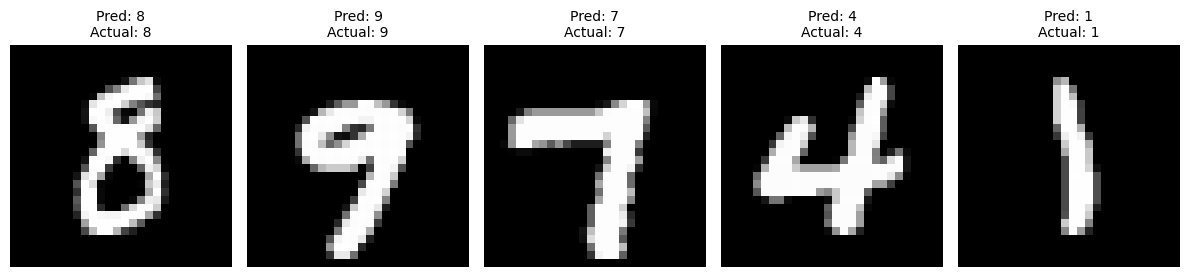

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(12, 5))
axes = axes.flatten()
idx = np.random.randint(0, len(x_test), size=10)

for i in range(5):
    axes[i].imshow(x_test[idx[i]].reshape(28, 28), cmap='gray')
    axes[i].axis('off')  # hide the axes ticks
    axes[i].set_title(f"Pred: {y_pred_test[idx[i]]}\nActual: {Y_test[idx[i]]}", color='black', fontsize=10)

plt.tight_layout()
plt.show()

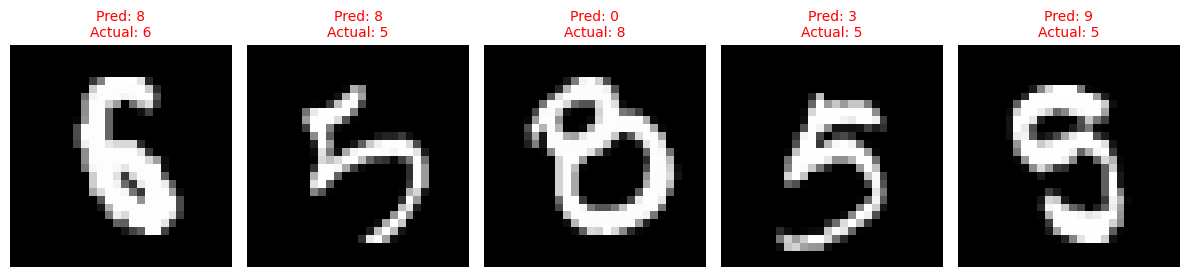

In [11]:
# Find indices where predictions don't match actual values
mismatch_indices = np.where(y_pred_test != Y_test)[0]

# Randomly select a few mismatched indices to display
selected_indices = np.random.choice(mismatch_indices, size=5, replace=False)

# Plot the mismatched images
fig, axes = plt.subplots(1, 5, figsize=(12, 5))
axes = axes.flatten()

for i, idx in enumerate(selected_indices):
    axes[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
    axes[i].axis('off')  # hide the axes ticks
    axes[i].set_title(f"Pred: {y_pred_test[idx]}\nActual: {Y_test[idx]}", color='red', fontsize=10)

plt.tight_layout()
plt.show()